# Import libraries

In [1]:

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models

# Load Datasets

In [2]:

dataset_path = r"D:\plant\plantvillage dataset\color"

IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


# Visualize and Normalize the Dataset

## Part A: Print Class Names

In [3]:


class_names = train_dataset.class_names

print("Number of Classes:", len(class_names))
print(class_names)

Number of Classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite

## Part B: Check Dataset Shape

In [4]:
for images, labels in train_dataset.take(1):

    print("Image Batch Shape :", images.shape)
    print("Label Batch Shape :", labels.shape)

Image Batch Shape : (32, 128, 128, 3)
Label Batch Shape : (32,)


## Part C: Display Sample Images

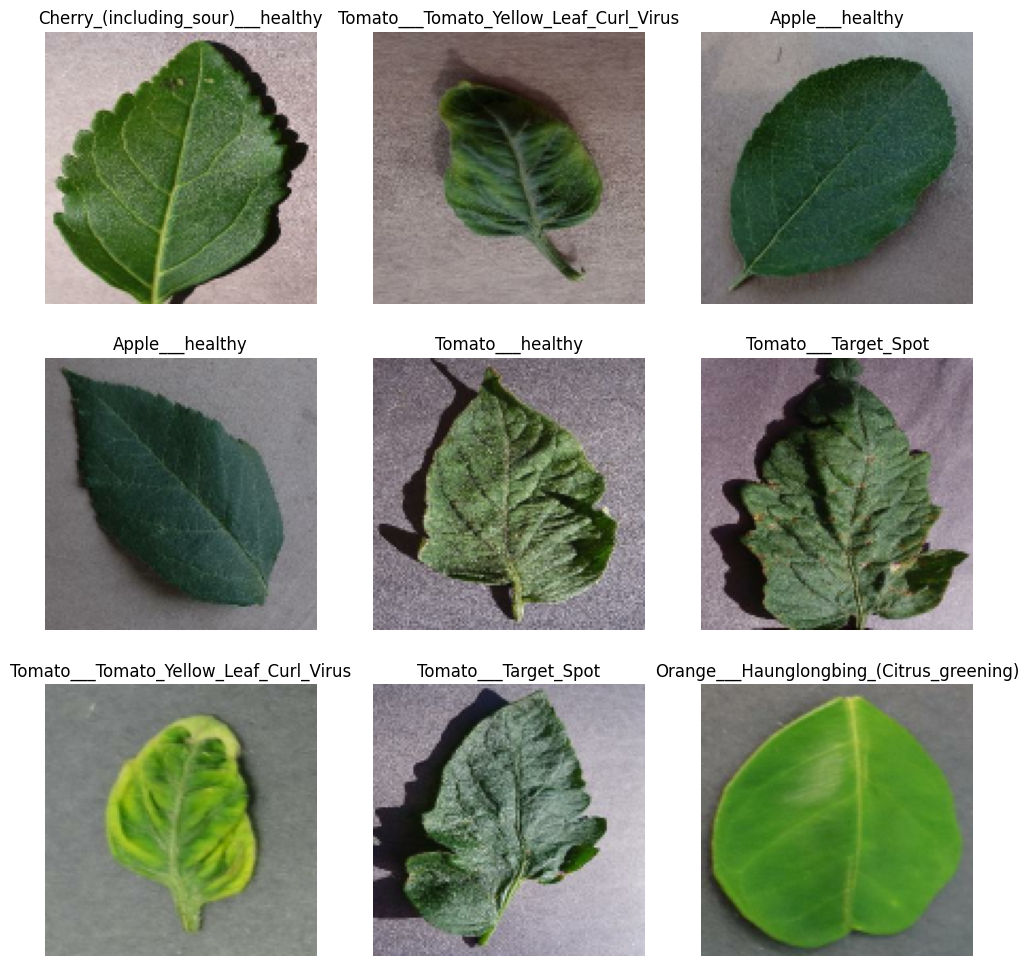

In [5]:
plt.figure(figsize=(12, 12))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

## Part D: Normalize Images

In [6]:
# Deep Learning models learn faster when inputs are between 0 and 1
normalization_layer = layers.Rescaling(1./255)

## Apply Normalization

In [7]:
train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

## Verify Normalization

In [8]:
for images, labels in train_dataset.take(1):

    print("Minimum Pixel Value :", images.numpy().min())
    print("Maximum Pixel Value :", images.numpy().max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 0.9960785


#  BUILD CNN MODEL

In [9]:


model = models.Sequential([

    # Input Layer
    layers.Input(shape=(128, 128, 3)),

    # Convolution Block 1
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Convolution Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Convolution Block 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Convert Feature Maps to Vector
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(256, activation='relu'),

    # Prevent Overfitting
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(38, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │           9,766 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,525,798 (24.89 MB)

 Trainable params: 6,525,798 (24.89 MB)

 Non-trainable params: 0 (0.00 B)

# Compile the CNN Model

In [10]:

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the CNN 

In [11]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 361s 265ms/step - accuracy: 0.5774 - loss: 1.4899 - val_accuracy: 0.7896 - val_loss: 0.6783
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 378s 278ms/step - accuracy: 0.7715 - loss: 0.7379 - val_accuracy: 0.8553 - val_loss: 0.4611
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 358s 263ms/step - accuracy: 0.8322 - loss: 0.5212 - val_accuracy: 0.8950 - val_loss: 0.3159
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 340s 251ms/step - accuracy: 0.8687 - loss: 0.4100 - val_accuracy: 0.9007 - val_loss: 0.3056
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 369s 272ms/step - accuracy: 0.8916 - loss: 0.3328 - val_accuracy: 0.9193 - val_loss: 0.2527
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 337s 248ms/step - accuracy: 0.9095 - loss: 0.2759 - val_accuracy: 0.9297 - val_loss: 0.2191
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 284s 209ms/step - accuracy: 0.9231 - loss: 0.2332 - val_accuracy: 0.9337 - val_loss: 0.2151
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 282s 207ms/step - ac

# Evaluate the Model

In [12]:

loss, accuracy = model.evaluate(validation_dataset)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

340/340 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.9408 - loss: 0.1918
Validation Loss: 0.19175918400287628
Validation Accuracy: 0.9407973289489746


# Plot Accuracy

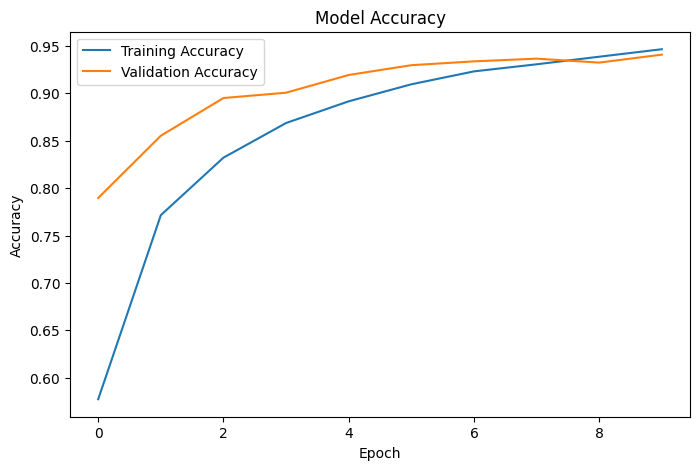

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# Plot Loss

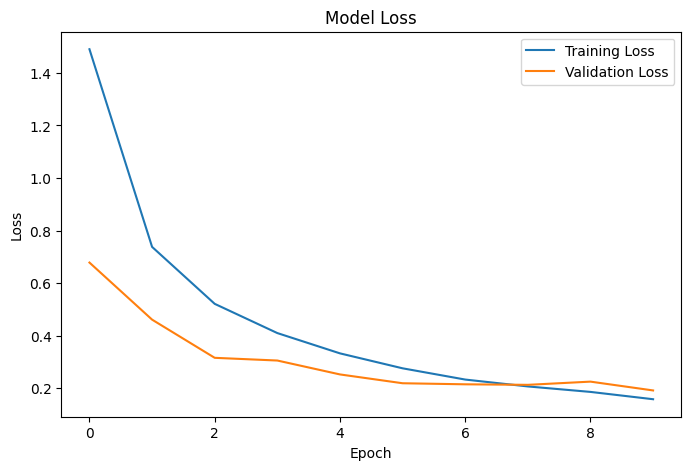

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# save TensorFlow(.keras) Model

In [15]:
model.save("plant_disease_model.keras")

print("Model saved successfully!")

print("Model Exists:",
      os.path.exists("plant_disease_model.keras"))

Model saved successfully!
Model Exists: True


# Convert into TFlite version for Lightweight and Faster Computation on mobile Deployment

In [16]:
# Create converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Convert the model
tflite_model = converter.convert()

# Save the TFLite model
with open("plant_disease_model.tflite", "wb") as f:
    f.write(tflite_model)

print("TensorFlow Lite model saved successfully!")

INFO:tensorflow:Assets written to: C:\Users\manda\AppData\Local\Temp\tmpkpu_1jz6\assets


INFO:tensorflow:Assets written to: C:\Users\manda\AppData\Local\Temp\tmpkpu_1jz6\assets


Saved artifact at 'C:\Users\manda\AppData\Local\Temp\tmpkpu_1jz6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  2025169418192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025169411280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025170451344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025174829200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025174839952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025170450768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025183869840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025183855824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025183863888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2025183858896: TensorSpec(shape=(), dtype=tf.resource, name=None)
Tensor